# Clustering visuel exploratoire — Ovide & Bibles

Regroupement des illustrations par **ressemblance visuelle**, sans thème imposé.
On calcule un *embedding* (vecteur visuel) pour chaque image, on regroupe les images
proches, et on regarde la composition de chaque groupe.

**Objectif** : voir si des illustrations d'Ovide et de Bibles se retrouvent dans les
mêmes groupes (indice d'une iconographie partagée — Déluge, Création…).

**Ce test** : une seule édition d'Ovide (Salomon) + quelques Bibles, pour valider la
méthode avant de l'étendre.

**Flux de travail** :
1. On choisit les dossiers.
2. On **copie** les illustrations de Bibles vers un dossier de travail `a_nettoyer/`
   (les sources restent intactes ; on y supprime à la main les images indésirables —
   lettrines, ornements, pages de texte).
3. Le clustering travaille sur le dossier nettoyé.

Chaque image garde son **origine** (édition / Bible) comme étiquette.

*Notebook prévu pour `notebooks/04_exploration/` — `RACINE` remonte de deux niveaux.*

## 1 · Imports

In [15]:
import os, sys, shutil
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from collections import Counter
import open_clip

RACINE = os.path.abspath("../../")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)

Device : cuda


## 2 · Choix des dossiers à tester

On prend **Salomon** (Ovide) + quelques Bibles. Modifie les listes pour ajuster le test.

In [6]:
DOSSIER_SEG         = os.path.join(RACINE, "data", "bois_cuivre", "segmentees")
DOSSIER_BIBLES_SRC  = os.path.join(RACINE, "data", "bibles_mdz", "segmentees")   # sources (intactes)
DOSSIER_BIBLES_WORK = os.path.join(RACINE, "data", "bibles_mdz", "a_nettoyer")   # copie de travail

# Édition(s) d'Ovide à inclure
DOSSIERS_OVIDE = ["bois_salomon_rouille_lyon1557"]

# Bibles choisies explicitement
DOSSIERS_BIBLES = [
    "bsb00085447",
    "bsb10141238",
    "bsb10169022",
    "bsb10212377",
    "bsb00079881",
]

# Vérifier qu'elles existent et ont des illustrations
print("Ovide  :", DOSSIERS_OVIDE, "\n")
print("Bibles choisies :")
for b in DOSSIERS_BIBLES:
    chemin = os.path.join(DOSSIER_BIBLES_SRC, b)
    if not os.path.isdir(chemin):
        print(f"   ⚠️  {b} : dossier introuvable")
        continue
    n = len([f for f in os.listdir(chemin)
             if f.lower().endswith((".jpg", ".jpeg", ".png"))
             and "_flip" not in f and not f.startswith("_tmp_")])
    print(f"   {b} : {n} illustrations")

Ovide  : ['bois_salomon_rouille_lyon1557'] 

Bibles choisies :
   bsb00085447 : 10 illustrations
   bsb10141238 : 10 illustrations
   bsb10169022 : 10 illustrations
   bsb10212377 : 10 illustrations
   bsb00079881 : 10 illustrations


## 3 · Copier les Bibles vers le dossier de travail

On copie (sans déplacer) les illustrations des Bibles choisies vers `a_nettoyer/`.
**Les sources ne sont pas modifiées.** Après cette cellule, ouvre le dossier dans
l'explorateur et supprime les images indésirables (celles qui ne contiennent que des
lettres, des ornements, etc.).

> Relançable : les fichiers déjà copiés sont écrasés à l'identique, donc tu peux
> recopier une Bible si besoin — mais tes suppressions manuelles seront alors perdues
> pour cette Bible. Copie d'abord, nettoie ensuite.

In [29]:
os.makedirs(DOSSIER_BIBLES_WORK, exist_ok=True)

def copier(dossier_base, sous_dossiers, etiquette):
    total = 0
    for d in sous_dossiers:
        src = os.path.join(dossier_base, d)
        dst = os.path.join(DOSSIER_BIBLES_WORK, d)
        if not os.path.isdir(src):
            print(f"  ⚠️ source introuvable : {d}")
            continue
        os.makedirs(dst, exist_ok=True)
        n = 0
        for f in os.listdir(src):
            if f.lower().endswith((".jpg", ".jpeg", ".png")) and "_flip" not in f and not f.startswith("_tmp_"):
                shutil.copy2(os.path.join(src, f), os.path.join(dst, f))
                n += 1
        total += n
        print(f"  [{etiquette}] {d:45s} : {n} illustrations copiées")
    return total

total_copie = 0
total_copie += copier(DOSSIER_SEG,        DOSSIERS_OVIDE,  "ovide")
total_copie += copier(DOSSIER_BIBLES_SRC, DOSSIERS_BIBLES, "bible")

print(f"\n✓ {total_copie} illustrations copiées vers :")
print(f"  {DOSSIER_BIBLES_WORK}")
print("\n→ Va nettoyer ce dossier (supprimer lettrines/ornements), PUIS lance la suite.")

  [ovide] bois_salomon_rouille_lyon1557                 : 161 illustrations copiées
  [bible] bsb00085447                                   : 10 illustrations copiées
  [bible] bsb10141238                                   : 10 illustrations copiées
  [bible] bsb10169022                                   : 10 illustrations copiées
  [bible] bsb10212377                                   : 10 illustrations copiées
  [bible] bsb00079881                                   : 10 illustrations copiées

✓ 211 illustrations copiées vers :
  /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/data/bibles_mdz/a_nettoyer

→ Va nettoyer ce dossier (supprimer lettrines/ornements), PUIS lance la suite.


## ⏸️ PAUSE — nettoyage manuel

Ouvre `data/bibles_mdz/a_nettoyer/` dans l'explorateur de fichiers et supprime les
illustrations indésirables (lettres seules, ornements, pages de texte).
Quand c'est fait, continue ci-dessous.

## 4 · Lister les images (depuis le dossier nettoyé) avec leur origine

Ovide est lu depuis les sources ; les Bibles depuis le dossier **nettoyé**.

In [43]:
images = []   # liste de dicts : chemin, origine, corpus

def ajouter(sous_dossiers, corpus):
    for d in sous_dossiers:
        chemin_d = os.path.join(DOSSIER_BIBLES_WORK, d)   # tout depuis le dossier nettoyé
        if not os.path.isdir(chemin_d):
            print(f"  ⚠️ introuvable : {d}")
            continue
        for f in os.listdir(chemin_d):
            if f.lower().endswith((".jpg", ".jpeg", ".png")) and "_flip" not in f and not f.startswith("_tmp_"):
                images.append({
                    "chemin": os.path.join(chemin_d, f),
                    "origine": d,
                    "corpus": corpus,
                })

ajouter(DOSSIERS_OVIDE,  "ovide")
ajouter(DOSSIERS_BIBLES, "bible")

print(f"{len(images)} images au total")
print(f"  ovide : {sum(1 for i in images if i['corpus']=='ovide')}")
print(f"  bible : {sum(1 for i in images if i['corpus']=='bible')}")

  ⚠️ introuvable : bsb00085447
  ⚠️ introuvable : bsb10141238
  ⚠️ introuvable : bsb10169022
  ⚠️ introuvable : bsb10212377
17 images au total
  ovide : 13
  bible : 4


## 5 · Extracteur d'embeddings (ResNet50 ImageNet)

**ResNet50 pré-entraîné ImageNet**, privé de sa dernière couche : chaque image devient
un vecteur de 2048 nombres résumant son contenu visuel.

> On n'utilise pas le modèle bois/cuivre : lui est spécialisé sur la *technique* de
> gravure, alors qu'on regroupe ici par *contenu* (le sujet représenté).

In [44]:
# CLIP comme extracteur sémantique + conversion niveaux de gris
modele_clip, _, preprocess_clip = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
modele_clip = modele_clip.to(DEVICE).eval()
print("CLIP ViT-B-32 chargé")

def embedding(chemin):
    img = Image.open(chemin).convert("RGB")
    # Niveaux de gris pour neutraliser le coloriage (puis re-RGB pour CLIP)
    img = img.convert("L").convert("RGB")
    x = preprocess_clip(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        vec = modele_clip.encode_image(x).cpu().numpy()[0]
    return vec

print("Extracteur prêt (CLIP + niveaux de gris)")

CLIP ViT-B-32 chargé
Extracteur prêt (CLIP + niveaux de gris)


## 6 · Calculer les embeddings

In [45]:
vecteurs, valides = [], []
print("Calcul des embeddings…")
for k, img in enumerate(images, 1):
    print(f"  {k}/{len(images)}", end="\r")
    try:
        vecteurs.append(embedding(img["chemin"]))
        valides.append(img)
    except Exception as e:
        print(f"\n  ignoré ({img['chemin']}) : {e}")

X = np.array(vecteurs)
images = valides
print(f"\n{X.shape[0]} embeddings calculés (dim {X.shape[1]})")

Calcul des embeddings…
  17/17
17 embeddings calculés (dim 512)


## 7 · Clustering (K-Means)

`N_CLUSTERS` à ajuster : trop peu = groupes fourre-tout ; trop = familles éclatées.

In [46]:
N_CLUSTERS = 4

km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels = km.fit_predict(X)
for i, img in enumerate(images):
    img["cluster"] = int(labels[i])

print(f"{N_CLUSTERS} clusters formés")

4 clusters formés


## 8 · Composition de chaque cluster

C'est ici qu'on voit si un groupe **mélange Ovide et Bibles**.

In [47]:
for c in range(N_CLUSTERS):
    membres = [img for img in images if img["cluster"] == c]
    n_ov = sum(1 for m in membres if m["corpus"] == "ovide")
    n_bi = sum(1 for m in membres if m["corpus"] == "bible")
    print(f"\n━━ CLUSTER {c} : {len(membres)} images  (ovide {n_ov} · bible {n_bi}) ━━")
    for orig, n in Counter(m["origine"] for m in membres).most_common():
        print(f"     {orig:45s} : {n}")


━━ CLUSTER 0 : 9 images  (ovide 9 · bible 0) ━━
     bois_salomon_rouille_lyon1557                 : 9

━━ CLUSTER 1 : 3 images  (ovide 0 · bible 3) ━━
     bsb00079881                                   : 3

━━ CLUSTER 2 : 4 images  (ovide 4 · bible 0) ━━
     bois_salomon_rouille_lyon1557                 : 4

━━ CLUSTER 3 : 1 images  (ovide 0 · bible 1) ━━
     bsb00079881                                   : 1


## 9 · Aperçu visuel par cluster

Jusqu'à 6 vignettes par cluster. Bordure **bleue = Ovide**, **rouge = Bible**.

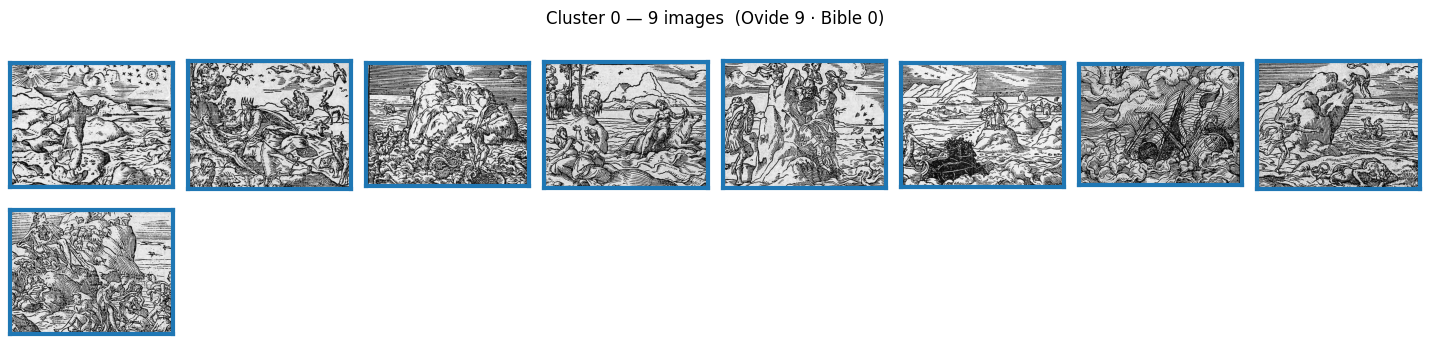

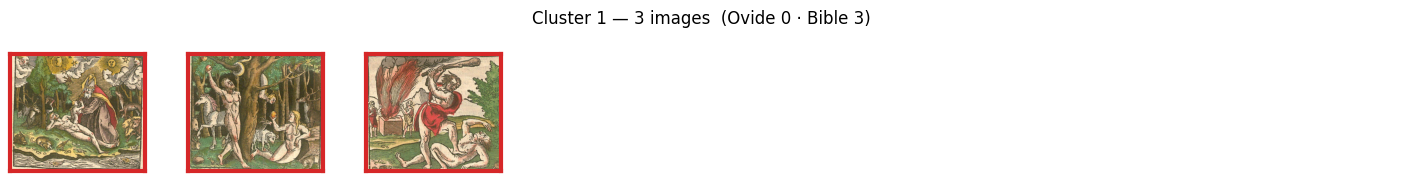

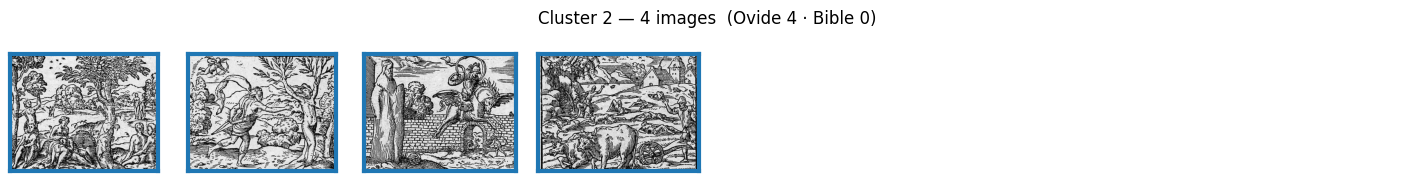

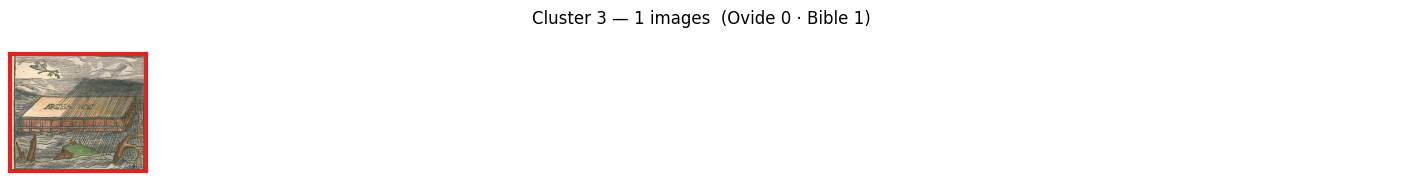

In [48]:
import math

def apercu_cluster(c, par_ligne=8, taille=1.8):
    """Affiche TOUTES les images d'un cluster donné."""
    membres = [img for img in images if img["cluster"] == c]
    if not membres:
        print(f"Cluster {c} vide")
        return
    n = len(membres)
    n_lignes = math.ceil(n / par_ligne)
    n_ov = sum(1 for m in membres if m["corpus"] == "ovide")
    n_bi = sum(1 for m in membres if m["corpus"] == "bible")

    fig, axes = plt.subplots(n_lignes, par_ligne,
                             figsize=(par_ligne*taille, n_lignes*taille))
    axes = np.array(axes).reshape(-1)   # aplatir pour itérer simplement
    for ax in axes:
        ax.axis("off")
    for ax, m in zip(axes, membres):
        try:
            ax.imshow(Image.open(m["chemin"]).convert("RGB"))
        except Exception:
            pass
        couleur = "tab:blue" if m["corpus"] == "ovide" else "tab:red"
        ax.set_xticks([]); ax.set_yticks([]); ax.axis("on")
        for spine in ax.spines.values():
            spine.set_edgecolor(couleur)
            spine.set_linewidth(3)
    fig.suptitle(f"Cluster {c} — {n} images  (Ovide {n_ov} · Bible {n_bi})", fontsize=12)
    plt.tight_layout()
    plt.show()

# Afficher TOUS les clusters, en entier
for c in range(N_CLUSTERS):
    apercu_cluster(c)

## Notes

- **Cluster mixte (bleu + rouge)** = illustrations d'Ovide et de Bibles visuellement
  proches → piste d'iconographie partagée (Déluge, Création…).
- **Cluster homogène** = famille propre à un corpus ou une édition.
- **Astuce nettoyage** : les lettrines/ornements se regroupent souvent dans un même
  cluster. Un premier passage peut donc aider à les repérer pour les supprimer du dossier
  `a_nettoyer/`, puis relancer.
- Pour étendre : ajouter des éditions et des Bibles aux listes (section 2), recopier
  (section 3), renettoyer, relancer. Sur tout le corpus (~5700 images), les embeddings
  prennent quelques minutes sur GPU.

In [50]:
import os, shutil
RACINE = os.path.abspath("../../")

SRC = os.path.join(RACINE, "data", "bibles_mdz", "segmentees")              # à garder intact
DST = os.path.join(RACINE, "data", "bibles_mdz", "regroupement")            # copie de travail

if os.path.exists(DST):
    print("⚠️ Le dossier de travail existe déjà :", DST)
    print("   (supprime-le d'abord si tu veux repartir d'une copie fraîche)")
else:
    shutil.copytree(SRC, DST)
    # Compter ce qui a été copié
    total = sum(len([f for f in os.listdir(os.path.join(DST, d))
                     if f.lower().endswith((".jpg",".jpeg",".png"))])
                for d in os.listdir(DST) if os.path.isdir(os.path.join(DST, d)))
    print(f"✓ Copie faite vers : {DST}")
    print(f"  {total} illustrations copiées (segmentees reste intact)")

✓ Copie faite vers : /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/data/bibles_mdz/regroupement
  674 illustrations copiées (segmentees reste intact)


In [2]:
import os, shutil
RACINE = os.path.abspath("../../")
SORTIE = os.path.join(RACINE, "data", "bibles_mdz", "classes_celine")
if os.path.isdir(SORTIE):
    shutil.rmtree(SORTIE)
    print("classes_celine/ vidé — l'atelier refera un clustering initial")

classes_celine/ vidé — l'atelier refera un clustering initial
